In [168]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass


In [169]:


from typing import Iterable


@dataclass
class SimulationParameters:
    executors: int
    transaction_time : float 
    database_size: int
    passwords_size: int
    mean_password_chars: int 
    mean_hash_time: float
    network_velocity: float
    disk_velocity: float
    cpu_speed: float
    hash_size : int 
    pass

@dataclass
class SimulationResult:
    total_time : float 
    comm_time : float 
    comp_time : float 
    speedup : float
    cc_ratio: float
    efficiency : float
    database_size : int 
    password_size : int 
    executors: int
    pass

class Simulation:
    def __init__(self, params: SimulationParameters):
        self.p = params
        pass

    def execute(self, executors: Iterable[int], database_size: Iterable)-> list[list[SimulationResult]]:
        results = []
        oldparams = self.p
        for i in database_size:
            instance = []
            for p in executors:
                self.p.executors = p
                self.p.database_size = i
                result = SimulationResult(
                    total_time=self.runtime(),
                    comm_time=self.t_comm(),
                    comp_time=self.t_comp(),
                    speedup=self.speedup(),
                    cc_ratio=self.t_comp()/self.t_comm(),
                    database_size=self.p.database_size,
                    password_size=self.p.passwords_size,
                    executors=self.p.executors,
                    efficiency=self.efficiency()
                )
                instance.append(result)
                pass
            results.append(instance)
        self.p = oldparams
        return results
    
    def t_comm(self) -> float:
        return NotImplemented
    def t_comp(self) -> float:
        return NotImplemented
    def t_seq(self)->float:
        return NotImplemented
    def space(self)-> float:
        return NotImplemented
    

    def runtime(self)-> float :
        return self.t_comp() + self.t_comm()
    def speedup(self) -> float:
        return self.t_seq()/self.runtime()
    def efficiency(self) -> float:
        return self.speedup() / self.p.executors
    def L(self,x):
        return x/ self.p.disk_velocity
    def S(self,x):
        return x / self.p.network_velocity
    def H(self,x):
        return self.p.mean_hash_time * x

    pass


md5_sim_param = SimulationParameters(
    executors=1,
    transaction_time=1*10**-8,
    database_size=100000,
    passwords_size=10000,
    mean_password_chars=16,
    mean_hash_time=2.5*10**-6,
    network_velocity=25*10**8,  # GB/s
    disk_velocity=2*10**8,       # GB/s
    cpu_speed=1.8*10**9,            # GHz
    hash_size=16                   # bytes
)




In [170]:
class BaseSimulation(Simulation):
    def t_seq_comm(self) -> float:
        return self.L(self.p.database_size*self.p.hash_size) + self.L(self.p.passwords_size*self.p.mean_password_chars) 

    def t_seq_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.p.database_size * self.p.passwords_size * 10**-7

    def t_seq(self) -> float:
        return self.t_seq_comm() + self.t_seq_comp()
    def t_comm(self) -> float:
        return self.t_seq_comm()
    def t_comp(self) -> float:
        return self.t_seq_comp()
    pass


print(BaseSimulation(md5_sim_param).runtime())


100.0338


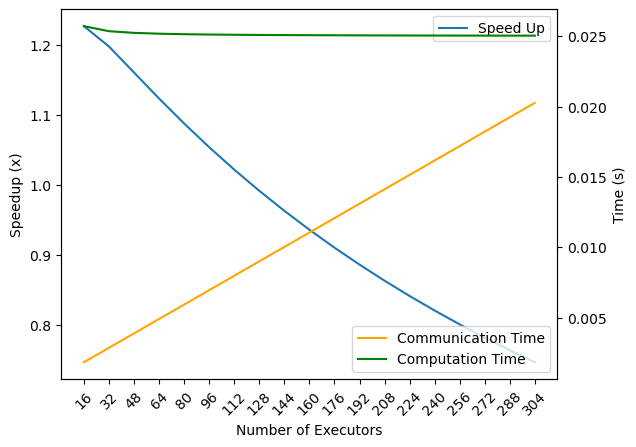

In [ ]:
from matplotlib.pyplot import xlabel, ylabel

class LinearSimulation(BaseSimulation):
    def t_comm(self) -> float:
        return self.L(self.p.passwords_size*self.p.mean_password_chars) + self.L(self.p.database_size*self.p.hash_size) + self.S(self.p.passwords_size*self.p.mean_password_chars) * self.p.executors + self.S(self.p.database_size*self.p.hash_size/self.p.executors)+ 2 * self.p.transaction_time * self.p.executors
    def t_comp(self) -> float:
        return self.H(self.p.passwords_size) + ((self.p.database_size * self.p.hash_size /self.p.executors) * self.p.passwords_size*self.p.hash_size) /self.p.cpu_speed
    pass



scale = LinearSimulation(md5_sim_param).execute([16*i for i in range(1,20)], [2**i for i in range(10,40)])

def plot_speedup(scale,index):
# set labels in plot
    xlabel('Number of Executors')
    ylabel('Speedup (x)')
    plt.plot([x for x in range(len(scale[index]))], [x.speedup for x in scale[index]] , label='Speed Up')
    # add to x the correct labels
    plt.xticks([x for x in range(len(scale[index]))], [f"{int(s.executors)}" for s in scale[index]], rotation=45)
    plt.legend()
    # add third axis 
    plt.twinx()
    plt.ylabel('Time (s)')
    plt.plot([x for x in range(len(scale[index]))], [s.comm_time for s in scale[index]], label='Communication Time', color='orange')
    plt.plot([x for x in range(len(scale[index]))], [s.comp_time for s in scale[index]], label='Computation Time', color='green')
    plt.legend()
    plt.show()

plot_speedup(scale,0)  # Plot for the first instance of scale

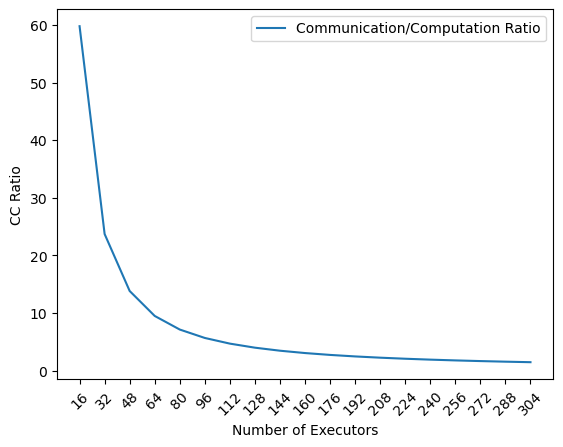

In [172]:
def plot_cc_ratio(scale,index):
    plt.plot([x for x in range(len(scale[index]))], [s.cc_ratio for s in scale[index]], label='Communication/Computation Ratio')
    plt.xticks([x for x in range(len(scale[index]))], [f"{int(s.executors)}" for s in scale[index]], rotation=45)
    plt.xlabel('Number of Executors')
    plt.ylabel('CC Ratio')
    plt.legend()
    plt.show()

plot_cc_ratio(scale,0)  # Plot for the first instance of scale

In [181]:
def plot_efficiency(scale,index):
    efficiency = [s.efficiency for s in scale[index]]
    plt.plot([x for x in range(len(efficiency))], efficiency, label='Efficiency', color='red')
    plt.xlabel('Number of Executors')
    plt.xticks([x for x in range(len(scale[index]))], [f"{int(s.executors)}" for s in scale[index]], rotation=45)
    plt.ylabel('Efficiency %')
    plt.legend()
    plt.show()

plot_efficiency(scale,9)  # Plot for the first instance of scale

IndexError: list index out of range

X shape: (7, 19) Y shape: (7, 19) Z shape: (7, 19)
Z min/max: 8.859556324774324 210.17021571169553


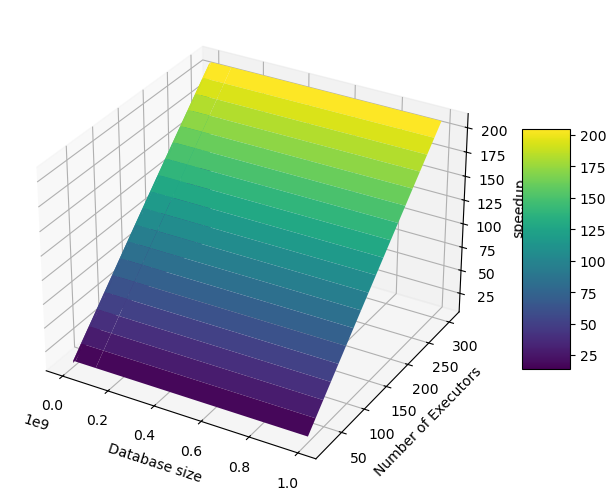

X shape: (7, 19) Y shape: (7, 19) Z shape: (7, 19)
Z min/max: 0.06746449390009186 0.7025456036324236


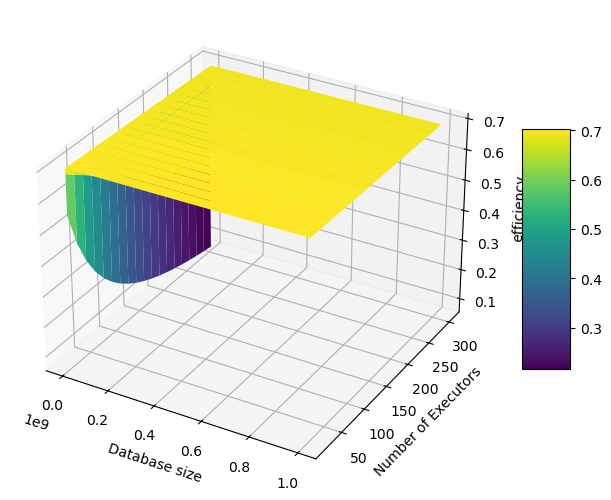

In [175]:
import math
from numpy import meshgrid


def plot_measure(result: list[list[SimulationResult]], measure: str):

    X_vals = [x[0].database_size for x in result]
    Y_vals = [x.executors for x in result[0]]  # <-- non dividere per 10
    X, Y = np.meshgrid(X_vals, Y_vals, indexing='ij')
    Z = np.zeros((len(X_vals), len(Y_vals)))
    for i in range(len(X_vals)):
        for j in range(len(Y_vals)):
            Z[i, j] = result[i][j].__getattribute__(measure)
    print("X shape:", X.shape, "Y shape:", Y.shape, "Z shape:", Z.shape)
    print("Z min/max:", np.nanmin(Z), np.nanmax(Z))
    fig = plt.figure()
    ax = fig.add_axes((0, 0, 1, 1), projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_xlabel('Database size')
    ax.set_ylabel('Number of Executors')
    ax.set_zlabel(measure)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    plt.show()

    
plot_measure(scale, 'speedup')
plot_measure(scale, 'efficiency')